In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

In [43]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
path = 'AmesHousingRaw.csv'
df = pd.read_csv(path)
print('Shape:', df.shape)
df.head(5)

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [44]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [46]:
df[['Lot Area', 'Gr Liv Area']].head()

,Lot Area,Gr Liv Area
0,31770,1656
1,11622,896
2,14267,1329
3,11160,2110
4,13830,1629


In [47]:
null_counts = df.isna().sum()
null_counts[null_counts > 0].sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

In [48]:
df_dropped = df.dropna(thresh=len(df)*0.75, axis=1)
df_dropped = df_dropped.drop(columns=['Order', 'PID'])
len(df_dropped.columns)

74

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0.101697
Kitchen AbvGr     -0

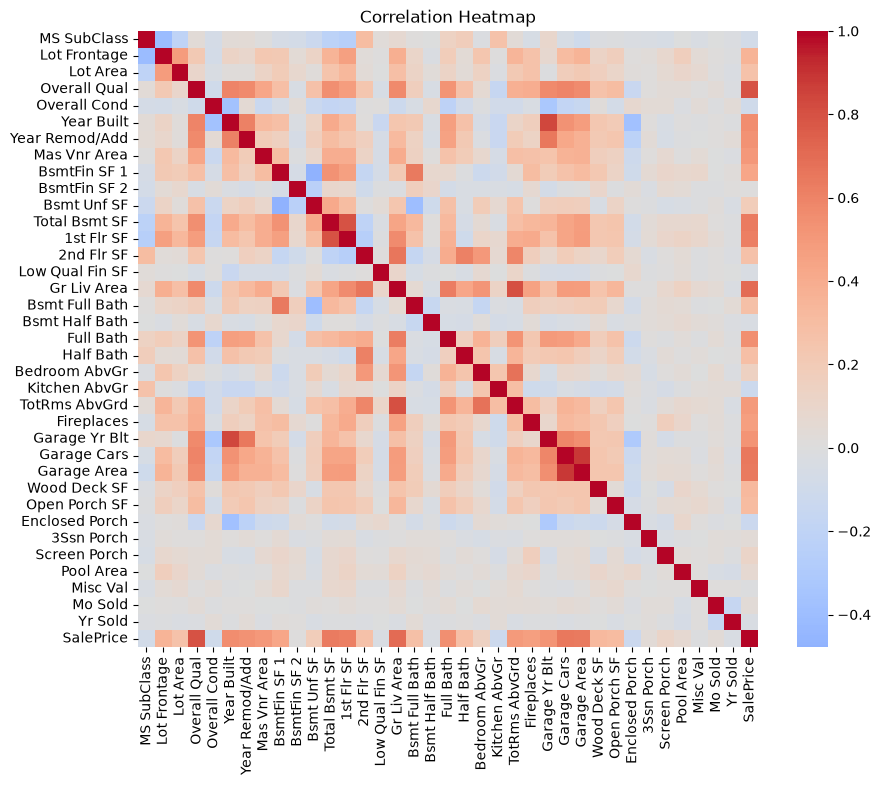

In [49]:
num_df = df_dropped.select_dtypes(include=['number'])
corr = num_df.corr()
corr_sale_price = num_df.corr()['SalePrice'].sort_values(ascending=False)
print(corr_sale_price)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, center=0, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [50]:
class AddFeatures:
    def __init__(self, df):
        self.df = df.copy()
        self.final_df = self.run()

    def add_total_sf(self):
        self.df['Total SF'] = self.df['1st Flr SF'] + self.df['2nd Flr SF'] + self.df['Total Bsmt SF']
        
    def add_finished_sf(self):
        self.df['Finished SF'] = (self.df['1st Flr SF'] + 
                                       self.df['2nd Flr SF'] + 
                                       self.df['Total Bsmt SF'] - 
                                       self.df['Bsmt Unf SF'])
        
    def add_high_quality_sf(self):
        self.df['Quality SF'] = (self.df['1st Flr SF'] + 
                                 self.df['2nd Flr SF'] + 
                                 self.df['Total Bsmt SF'] - 
                                 self.df['Low Qual Fin SF'])
    def add_finished_bsmt_area(self):
        self.df['Fin Bsmt Area'] = (self.df['Total Bsmt SF'] - self.df['Bsmt Unf SF'])
        
    def add_total_bath(self):
        self.df['Total Bath'] = self.df['Full Bath'] + self.df['Half Bath'] + self.df['Bsmt Full Bath'] + self.df['Bsmt Half Bath']

    def run(self):
        self.add_total_sf()
        self.add_finished_sf()
        self.add_high_quality_sf()
        self.add_finished_bsmt_area()
        self.add_total_bath()
        return self.df

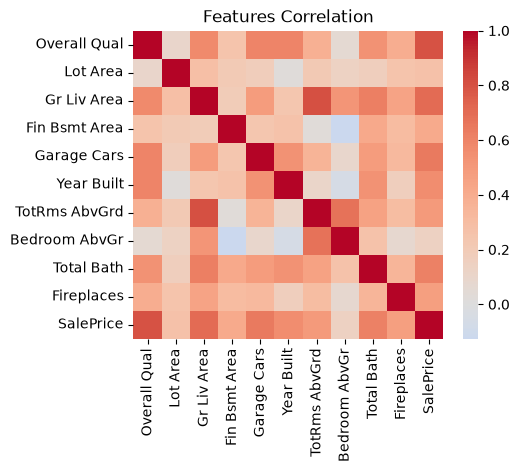

In [51]:
feature_engineer = AddFeatures(df_dropped)
useful_features = ['Overall Qual', 'Lot Area', 'Gr Liv Area', 'Fin Bsmt Area', 'Garage Cars', 'Year Built', 
                   'TotRms AbvGrd', 'Bedroom AbvGr', 'Total Bath', 'Fireplaces', 'SalePrice']
engineered_df = feature_engineer.final_df[useful_features]
corr_engineered = engineered_df.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_engineered, annot=False, center=0, cmap='coolwarm')
plt.title('Features Correlation')
plt.show()

In [52]:
df2 = feature_engineer.final_df
null_counts2 = df2.isna().sum()
null_counts2[null_counts2 > 0].sort_values(ascending=False)

Lot Frontage      490
Garage Finish     159
Garage Qual       159
Garage Cond       159
Garage Yr Blt     159
Garage Type       157
Bsmt Exposure      83
BsmtFin Type 2     81
Bsmt Cond          80
BsmtFin Type 1     80
Bsmt Qual          80
Mas Vnr Area       23
Bsmt Full Bath      2
Total Bath          2
Bsmt Half Bath      2
Bsmt Unf SF         1
BsmtFin SF 1        1
BsmtFin SF 2        1
Garage Cars         1
Total Bsmt SF       1
Electrical          1
Garage Area         1
Total SF            1
Finished SF         1
Quality SF          1
Fin Bsmt Area       1
dtype: int64

In [53]:
df2['Bldg Type'].value_counts()  

Bldg Type
1Fam      2425
TwnhsE     233
Duplex     109
Twnhs      101
2fmCon      62
Name: count, dtype: int64

In [54]:
cat_cols = df2.select_dtypes(exclude='number').columns
df2_cleaned = df2.dropna(subset=cat_cols)
num_df2 = df2_cleaned.select_dtypes(include='number')
cat_df2 = df2_cleaned.select_dtypes(exclude='number').reset_index(drop=True)
imputer = KNNImputer()
num_df2_imputed = pd.DataFrame(imputer.fit_transform(num_df2), columns=num_df2.columns).reset_index(drop=True)
df3 = pd.concat([num_df2_imputed[useful_features], cat_df2[['Neighborhood']]], axis=1)
df3.dtypes


Overall Qual     float64
Lot Area         float64
Gr Liv Area      float64
Fin Bsmt Area    float64
Garage Cars      float64
Year Built       float64
TotRms AbvGrd    float64
Bedroom AbvGr    float64
Total Bath       float64
Fireplaces       float64
SalePrice        float64
Neighborhood         str
dtype: object

In [55]:
cat_cols = df3.select_dtypes(exclude='number').columns
df_encoded = pd.get_dummies(
    df3,
    columns=cat_cols,
    drop_first=True,
)
df_encoded.columns

Index(['Overall Qual', 'Lot Area', 'Gr Liv Area', 'Fin Bsmt Area',
       'Garage Cars', 'Year Built', 'TotRms AbvGrd', 'Bedroom AbvGr',
       'Total Bath', 'Fireplaces', 'SalePrice', 'Neighborhood_Blueste',
       'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_Greens', 'Neighborhood_GrnHill',
       'Neighborhood_IDOTRR', 'Neighborhood_Landmrk', 'Neighborhood_MeadowV',
       'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Timber', 'Neighborhood_Veenker'],
      dtype='str')

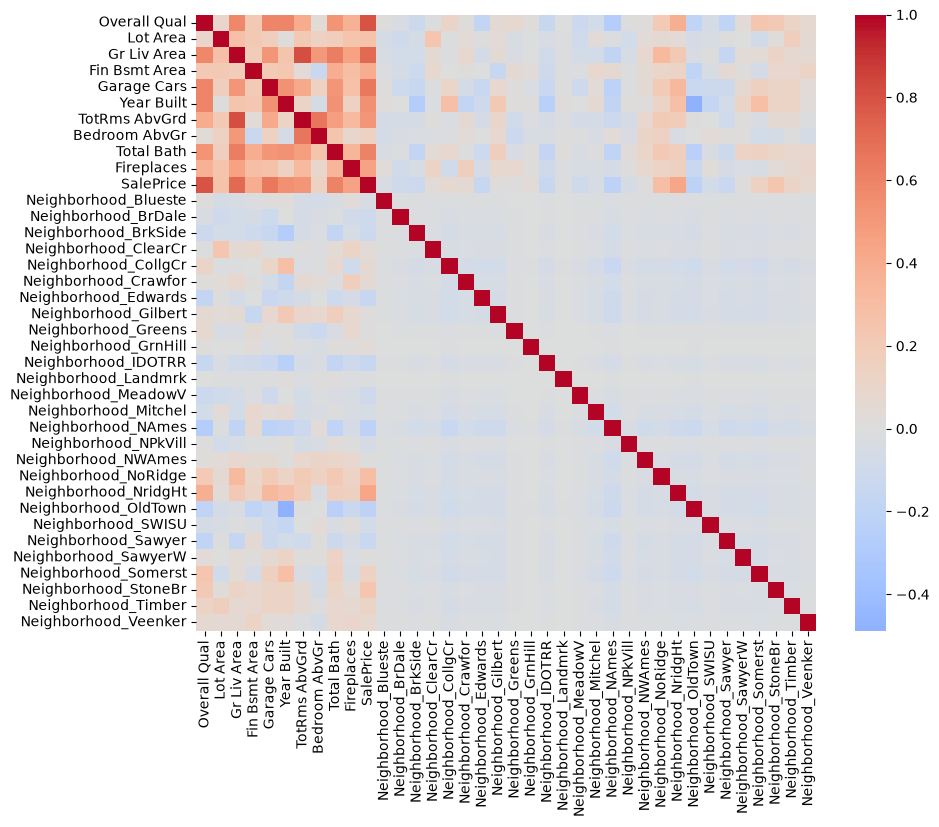

In [56]:
corr_encoded = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_encoded, annot=False, center=0, cmap='coolwarm')
plt.show()

In [57]:
"""
df4 = pd.get_dummies(df3, columns=['Bldg Type'], dtype=int)
df4 = df4.drop(columns=['Bldg Type_2fmCon'])
"""

"\ndf4 = pd.get_dummies(df3, columns=['Bldg Type'], dtype=int)\ndf4 = df4.drop(columns=['Bldg Type_2fmCon'])\n"

In [58]:
def move_column(df, col_name, new_index_pos):
    col_to_move = df.pop(col_name)
    df.insert(new_index_pos, col_name, col_to_move)

In [64]:
df5 = df3.copy()
df5 = df5.rename(columns={'Gr Liv Area': 'Living Area', 
                          'TotRms AbvGrd': 'Total Rooms',
                          'Bedroom AbvGr': 'Bedrooms', 
                          'Total Bath': 'Bathrooms',
                          })
df5['Has Basement'] = np.where(df5['Fin Bsmt Area'] > 0, 1, 0)
df5.drop(columns='Fin Bsmt Area', inplace=True)
move_column(df5, 'Has Basement', 3)
move_column(df5, 'SalePrice', df5.shape[1]-1)
df5.columns

Index(['Overall Qual', 'Lot Area', 'Living Area', 'Has Basement',
       'Garage Cars', 'Year Built', 'Total Rooms', 'Bedrooms', 'Bathrooms',
       'Fireplaces', 'Neighborhood', 'SalePrice'],
      dtype='str')

In [65]:
df5.to_csv("AmesHousingClean.csv", index=False)

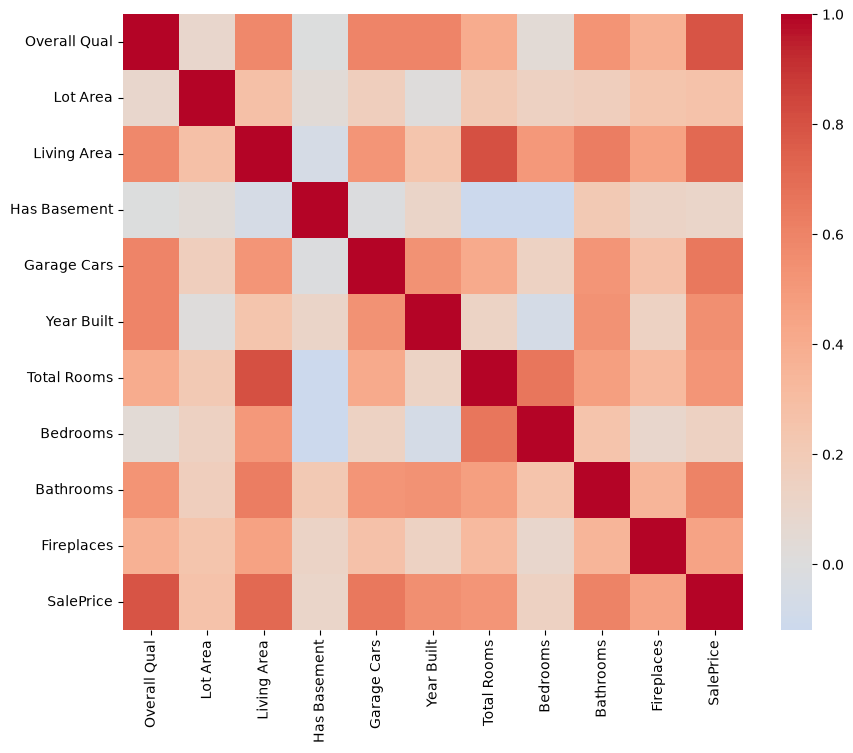

In [66]:
corr5 = df5.drop(columns='Neighborhood').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr5, annot=False, center=0, cmap='coolwarm')
plt.show()

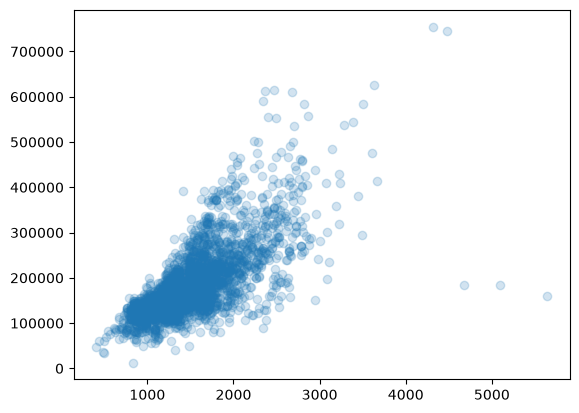

In [63]:
plt.scatter(df5['Living Area'], df5['SalePrice'], alpha=0.2)
plt.show()